# Model Evaluation





In [4]:
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# dataset
from sklearn.datasets import load_digits
cancer = load_breast_cancer()
iris = load_iris()
diabetes = load_diabetes()
digits = load_digits()

In [2]:
# load data and format it as dataframe
iris = load_iris()
df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],columns= list(iris['feature_names']) + ['target'])
df['target_names'] = iris.target_names[df['target'].astype(int)]
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica


# Data Split to train and test part

In [5]:
from sklearn.model_selection import train_test_split
# we can use data in dataframe, then some methods give back the warning
#  UserWarning: X has feature names, but LogisticRegression was fitted without feature names f"X has feature names, but {self.__class__.__name__} was fitted without"

df_X = df.iloc[:,:-2]
df_y = df['target']
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, random_state=0) #Allowed inputs are lists, numpy arrays, scipy-sparse matrices or pandas dataframes.
print(type((X_train)))

NameError: name 'df' is not defined

In [6]:
# so, further we work with array, which is faster

X = iris.data
print(type(X))
y = iris.target
print(type(y))

# Split arrays or matrices into random train and test subsets
# Test data is by defauls 25% of dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) #Allowed inputs are lists, numpy arrays, scipy-sparse matrices or pandas dataframes.
# ?train_test_split
print(type((X_train)))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [7]:
# scale on train data and apply scaler on test data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
print(type((X_train_scaled)))

# initiate the svc model
model = SVC()

# train the model on train data
model.fit(X_train_scaled, y_train)

# evaluate the model on the test data scaled by previously defined and trained scaler
X_test_scaled = scaler.transform(X_test) # transform text data by using scaler, not fit, just transform

print("Train set score: {:.2f}%".format(100*model.score(X_train_scaled, y_train)))

print("Test set score without scaling of test data: {:.2f}%".format(100*model.score(X_test, y_test))) # wrong!!!
print("Test set score: {:.2f}%".format(100*model.score(X_test_scaled, y_test)))

# result for unscalled data is ok because the features have similar scale
model.fit(X_train, y_train)
print("Test set score with scaling the data: {:.2f}%".format(100*model.score(X_test, y_test))) # wrong!!!

<class 'numpy.ndarray'>
Train set score: 97.32%
Test set score without scaling of test data: 23.68%
Test set score: 97.37%
Test set score with scaling the data: 97.37%


# Cross-Validation

## flowchart of typical cross validation workflow in model training
![title](https://drive.google.com/uc?id=1E2W9NB9gPN8FukKNLiXpdIaa5h3aBohO)

In [8]:
from sklearn.model_selection import cross_val_score

model = SVC()
# Evaluate a score by cross-validation.
scores = cross_val_score(model, X, y, cv=5) # cv parameter => or use the default 5-fold cross validation

print("Cross-validation scores: {}".format(scores)) # reports only accuracy as score
# if other scoring needs to be used, check https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
# and use scoring parameter
# By default, parameter search uses the score function of the estimator to evaluate a parameter setting.
# These are the sklearn.metrics.accuracy_score for classification and sklearn.metrics.r2_score for regression...


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scores = cross_val_score(model, X_scaled, y)
Scores = [round(100*score,2) for score in scores]
# print(Scores)
print("Cross-validation scores, each for one fold of data: {}%".format(Scores))

Cross-validation scores: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Cross-validation scores, each for one fold of data: [np.float64(96.67), np.float64(96.67), np.float64(96.67), np.float64(93.33), np.float64(100.0)]%


In [14]:
# scaling and training can be done with CV by using pipeline
from sklearn.pipeline import Pipeline

scaler = StandardScaler()
model = SVC()

pipeline = Pipeline([('scaler', scaler), ('model', model)]) # Pipeline of transforms (scaler) with a final estimator (model).

scores = cross_val_score(pipeline, X, y) # default 5 folds
Scores = [round(100*score,2) for score in scores]
print("Cross-validation scores: {}%".format(Scores))

Cross-validation scores: [np.float64(96.67), np.float64(96.67), np.float64(96.67), np.float64(93.33), np.float64(100.0)]%


# Grid Search

In [15]:
# Simple grid search for hypermarameters of models

# naive grid search implementation
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=10)
print("Size of training set: {}  size of test set: {}".format(X_train.shape[0], X_test.shape[0]))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# search systematically for two parameters
best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]: # kernel coef
  for C in [0.001, 0.01, 0.1, 1, 10, 100]: # regularization param
# for each combination of parameters, train an SVC
    svm = SVC(gamma=gamma, C=C)
    svm.fit(X_train_scaled, y_train)

    # evaluate the SVC on the test set
    score = svm.score(X_test_scaled, y_test)
    # if we got a better score, store the score and parameters
    if score > best_score:
      best_score = score
      best_parameters = {'C': C, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))


Size of training set: 112  size of test set: 38
Best score: 1.00
Best parameters: {'C': 100, 'gamma': 0.001}


## Danger of overfitting parameters in previous example of grid search
 - only 1 split to train and test
 - to avoid it - we introduce the validation set

In [16]:
# split data into train+validation set and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=10)

scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled = scaler.transform(X_test)

# split train+validation set into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval_scaled, y_trainval, random_state=1)
print("Size of training set: {} size of validation set: {} size of test set:" " {}\n".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))


best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
  for C in [0.001, 0.01, 0.1, 1, 10, 100]:
# for each combination of parameters, train an SVC
    svm = SVC(gamma=gamma, C=C)
    svm.fit(X_train, y_train)
    # evaluate the SVC on the test set
    score = svm.score(X_valid, y_valid)
    # if we got a better score, store the score and parameters
    if score > best_score:
      best_score = score
      best_parameters = {'C': C, 'gamma': gamma}

# rebuild a model on the combined training and validation set - using best parameters found within train+validation data
# and evaluate it on the test set
svm = SVC(**best_parameters) # initiate model with parameters found in grid search
svm.fit(X_trainval_scaled, y_trainval) # fit the model on train+validation data
test_score = svm.score(X_test_scaled, y_test) # get score for model with best found parameters

print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))

# 2 problems in above code
# 1) validation data are scaled together with training - common thing and usually not a big problem
# 2) we get the score only for one chunk of validation dataset per parameters, depends on random_satate parameter in train_test_split


Size of training set: 84 size of validation set: 28 size of test set: 38

Best score on validation set: 0.96
Best parameters:  {'C': 100, 'gamma': 0.001}
Test set score with best parameters: 1.00


# Grid Search with Cross-Validation



In [17]:
X_trainval, X_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=10)
best_score = 0

# using pipeline to scale data for CV
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
  for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    # for each combination of parameters,
    # train an SVC
    svm = SVC(gamma=gamma, C=C)

    #adopt pipeline with scaling
    scaler = StandardScaler()
    pipeline = Pipeline([('transformer', scaler), ('estimator', svm)])

    # perform cross-validation
    scores = cross_val_score(pipeline, X_trainval, y_trainval, cv=10)
    # compute mean cross-validation accuracy
    score = np.mean(scores)
    # if we got a better score, store the score and parameters
    if score > best_score:
      best_score = score
      best_parameters = {'C': C, 'gamma': gamma}
# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
pipeline = Pipeline([('transformer', scaler), ('estimator', svm)])

pipeline.fit(X_trainval, y_trainval)

# using only test set to evaluate
test_score = pipeline.score(X_test, y_test)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))


Best score on validation set: 0.97
Best parameters:  {'C': 100, 'gamma': 0.01}
Test set score with best parameters: 0.97


In [1]:
# using GridSearchCV - GridSearchCV performs crossvalidation of training data (splits, fits, gets score in k-fold, returns model with best parameters)
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=10)
svc = SVC()
scaler = StandardScaler()

X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pipeline = Pipeline([('transformer', scaler), ('estimator', svc)])

param_grid = {
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'estimator__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }

grid_search1 = GridSearchCV(pipeline, param_grid, cv=10) # search using pipeline

grid_search1.fit(X_train, y_train)
print("Best parameters - with pipeline: {}".format(grid_search1.best_params_))
print("Best cross-validation score - with pipeline: {:.2f}".format(grid_search1.best_score_))

# using only test set to evaluate
test_score1 = grid_search1.score(X_test, y_test)
print("Test set score with best parameters - with pipeline: {:.2f}".format(test_score1))


###
# search without pipeline. (6x6 combinations)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }

grid_search2 = GridSearchCV(svc, param_grid, cv=10)

grid_search2.fit(X_train_scaled, y_train)
print("Best parameters - w/o pipeline: {}".format(grid_search2.best_params_))
print("Best cross-validation score - w/o pipeline: {:.2f}".format(grid_search2.best_score_))

test_score2 = grid_search2.score(X_test_scaled, y_test)
print("Test set score with best parameters - w/o: {:.2f}".format(test_score2))


NameError: name 'train_test_split' is not defined

In [19]:
print("Best estimator:\n{}".format(grid_search1.best_estimator_))


Best estimator:
Pipeline(steps=[('transformer', StandardScaler()),
                ('estimator', SVC(C=10, gamma=0.1))])


In [20]:
print("Best estimator:\n{}".format(grid_search2.best_estimator_))


Best estimator:
SVC(C=10, gamma=0.1)


## Analyzing the result of cross-validation


In [33]:
# convert to DataFrame
results = pd.DataFrame(grid_search1.cv_results_)
# show the first 5 rows
display(results)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001440,0.000106,0.000749,0.000025,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
1,0.001358,0.000016,0.000729,0.000016,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
2,0.001512,0.000338,0.000851,0.000216,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
3,0.001370,0.000016,0.000732,0.000015,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
4,0.001411,0.000078,0.000753,0.000037,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.363636,0.454545,0.357576,0.042424,31
5,0.001579,0.000038,0.000780,0.000034,0.001,100.000,"{'C': 0.001, 'gamma': 100}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.363636,0.454545,0.357576,0.042424,31
6,0.001415,0.000039,0.000777,0.000096,0.010,0.001,"{'C': 0.01, 'gamma': 0.001}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
7,0.001610,0.000208,0.001057,0.000618,0.010,0.010,"{'C': 0.01, 'gamma': 0.01}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
8,0.001666,0.000280,0.000846,0.000088,0.010,0.100,"{'C': 0.01, 'gamma': 0.1}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19
9,0.001486,0.000110,0.000779,0.000023,0.010,1.000,"{'C': 0.01, 'gamma': 1}",0.333333,0.333333,0.363636,0.363636,0.363636,0.363636,0.363636,0.272727,0.636364,0.636364,0.403030,0.119726,19


## Nested CV
 - before only one split to train and test - and 5 folds in train to trainval and val

In [ ]:
# Two cross-validation loops are performed in parallel:
# one by the GridSearchCV estimator to set gamma and C
# and the other one by cross_val_score to measure the prediction performance of the estimator.
# The resulting scores are unbiased estimates of the prediction score on new data.

param_grid = {
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'estimator__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }
svc = SVC()
scaler = StandardScaler()
pipeline = Pipeline([('transformer', scaler), ('estimator', svc)])

search = GridSearchCV(pipeline, param_grid, cv=10)

scores = cross_val_score(search, iris.data, iris.target, cv=5)
# what happens here with data?
# for 5 folds - it finds best params for SVC using grid search splitting data into 10 folds
print("Cross-validation scores: ", scores)
print("Mean cross-validation score: ", scores.mean())

# this example does allow you to get best parameters to be used later because it finds 5 diferent best params...

Cross-validation scores:  [0.96666667 1.         0.9        0.93333333 1.        ]
Mean cross-validation score:  0.96


# Evaluate Classifiers

## Confusion Matrix

Confusion matrix:
[[11  0  0]
 [ 0 14  1]
 [ 0  0 12]]


<Axes: >

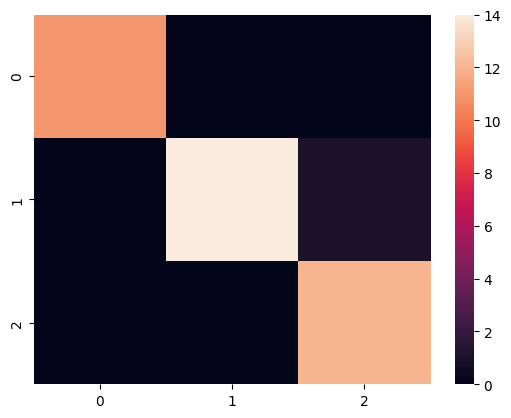

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = grid_search1.best_estimator_.predict(X_test)
confusion = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n{}".format(confusion))
sns.heatmap(confusion)

## Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))

# macro vs weighted average - macro - 0.5 weights, weighted - class support defines the weight in %

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.93      0.97        15
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.98        38
weighted avg       0.98      0.97      0.97        38



## ROC, AUC
- ROC is a graph showing the performance of a classification model at all classification thresholds.

### two classes example of decision threshold

  Using cached joblib-1.1.0-py2.py3-none-any.whl (306 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.3.2
    Uninstalling joblib-1.3.2:
      Successfully uninstalled joblib-1.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.10.1 requires joblib>=1.1.1, but you have joblib 1.1.0 which is incompatible.
scikit-learn 1.2.2 requires joblib>=1.1.1, but you have joblib 1.1.0 which is incompatible.


  Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


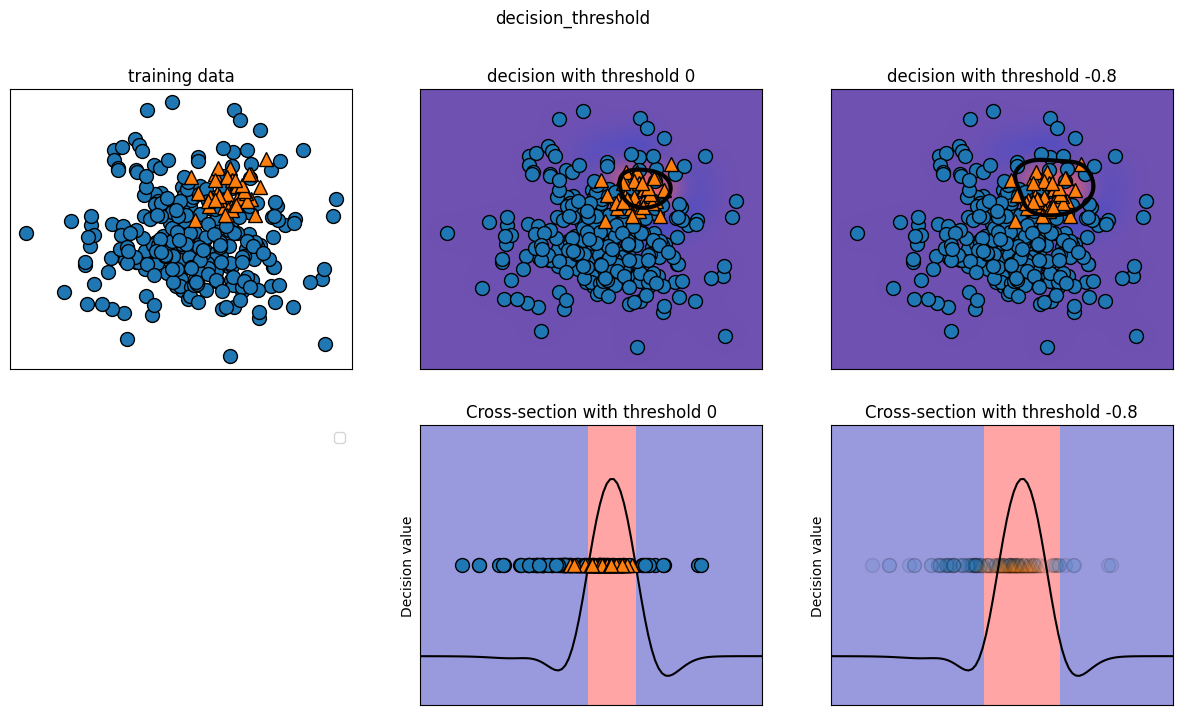

In [ ]:
!pip install --upgrade joblib==1.1.0
!pip install mglearn
import mglearn
mglearn.plots.plot_decision_threshold()

In [ ]:
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(random_state=22, centers=None,cluster_std=[7.0, 2], n_samples=[400, 50])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)

# sns.scatterplot(X[:, 0], X[:, 1], hue=y, s=60)
# plt.figure()
# sns.scatterplot(X_train[:, 0], X_train[:, 1], hue=y_train, s=60)
# plt.figure()
# sns.scatterplot(X_test[:, 0], X_test[:, 1], hue=y_test, s=60)

In [ ]:
print(classification_report(y_test, svc.predict(X_test)))


              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



In [ ]:
y_pred_lower_threshold = svc.decision_function(X_test) > -0.8
print(classification_report(y_test, y_pred_lower_threshold))


              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



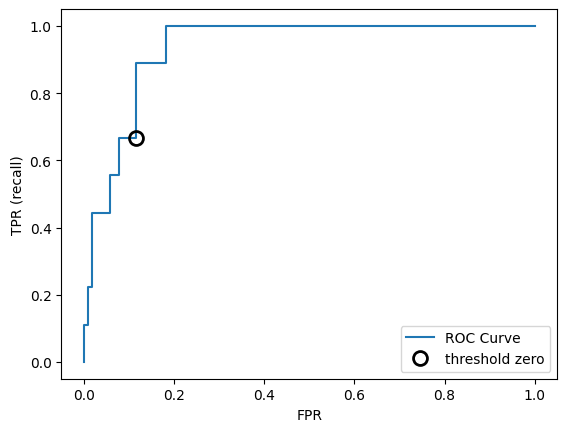

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(X_test))
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
label="threshold zero", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)


In [ ]:
from sklearn.metrics import roc_auc_score
svc_auc = roc_auc_score(y_test, svc.decision_function(X_test))
print("AUC for SVC: {:.3f}".format(svc_auc))


AUC for SVC: 0.934


- The RandomForestClassifier doesn’t have a decision_function, only
predict_proba.  
- roc_curve(y_test, rf.predict_proba(X_test)[:, 1])


## ROC for multiclass - one vs the rest

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

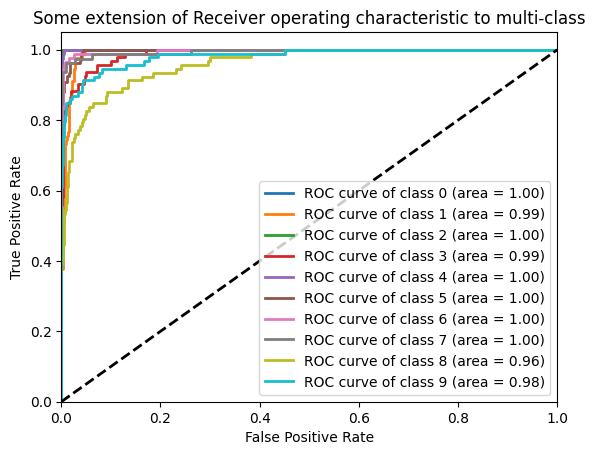

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from numpy import interp
from sklearn.metrics import roc_auc_score, auc
from itertools import cycle
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
digits = load_digits()

#display(pd.DataFrame(digits.target))
# Import some data to play with
X = digits.data

display(X)
y = digits.target
#print(y)
# Binarize the output
y = label_binarize(y, classes=list(set(digits.target))) #[0,1,2,3,4,5,6,7,8,9]
#print(y)
n_classes = y.shape[1]

# shuffle and split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5, random_state=0)

# Learn to predict each class against the other
classifier = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=0))
y_score = classifier.fit(X_train, y_train).decision_function(X_test)
#print("---"*10)
#print("y_test", y_test[:,2])
#print("---"*10)
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")

### Multiclass classification:
Specifically, there are 3 averaging techniques applicable to multiclass classification:
- macro:
  - this is a simple arithmetic mean of all metrics across classes. This technique gives equal weights to all classes making it a good option for balanced classification tasks.

- weighted:
  - accounts for class imbalance by computing the average of binary metrics weighted by the number of samples of each class in the target. If 3 (precision scores) for 3 classes are: Class 1 (0.85), class 2 (0.80), and class 3 (0.89), the weighted average will be calculated by multiplying each score by the number of occurrences of each class and dividing by the total number of samples

- micro:
  - this is the same as accuracy. Micro-averaging is found by dividing the sum of the diagonal cells of the matrix by the sum of all the cells — i.e., accuracy. As accuracy is such a misleading metric, this averaging technique is rarely used.

- "macro" averaging computes the unweighted per-class f-scores. This gives equal
weight to all classes, no matter what their size is.
- "weighted" averaging computes the mean of the per-class f-scores, weighted by
their support. This is what is reported in the classification report.
- "micro" averaging computes the total number of false positives, false negatives,
and true positives over all classes, and then computes precision, recall, and f-
score using these counts.


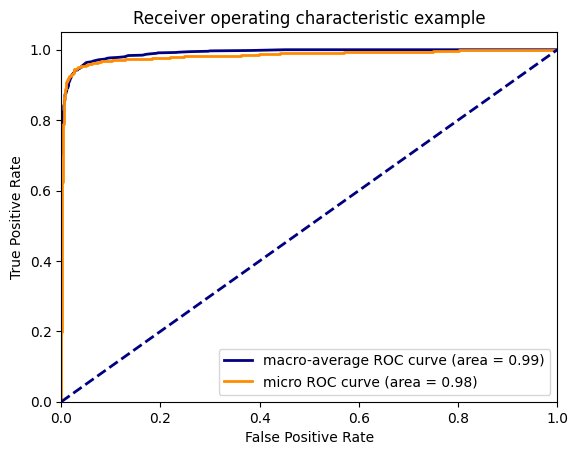

In [ ]:
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC macro curves
plt.plot(fpr["macro"], tpr["macro"], label='macro-average ROC curve (area = {0:0.2f})'''.format(roc_auc["macro"]),
         color='navy', linewidth=2)

plt.plot(fpr["micro"], tpr["micro"], color='darkorange', lw=2, label='micro ROC curve (area = %0.2f)' % roc_auc["micro"])
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()


## Cohen Kappa for Multiclass Classification

In [ ]:
# The function cohen_kappa_score computes Cohen’s kappa statistic.
# This measure is intended to compare labelings by different human annotators, not a classifier versus a ground truth.
# compute change agreement = sum of chances agreement for individual classes, and agreement =  the sum of all the grades both people agreed on divided by the total number of occurrences.
# The kappa score is a number between -1 and 1.
# Scores above .8 are generally considered good agreement; zero or lower means no agreement (practically random labels).
# examples: https://www.mydatamodels.com/blog/multiclass-classification-metrics/
# Kappa scores can be computed for binary or multiclass problems, but not for multilabel problems
# (except by manually computing a per-label score) and not for more than two annotators.

from sklearn.metrics import cohen_kappa_score
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
clf = SVC(kernel='linear',random_state=0)
clf.fit(X_train, y_train)

y_true = y_test
y_pred = clf.predict(X_test)

print('kappa score', cohen_kappa_score(y_true, y_pred))
confusion = confusion_matrix(y_test, y_pred)
# sns.heatmap(confusion)
print(confusion)
print(classification_report(y_test, y_pred))


kappa score 0.9641222466566299
[[ 89   0   0   0   0   0   0   0   0   0]
 [  0  86   0   0   0   1   1   0   2   0]
 [  0   1  91   0   0   0   0   0   0   0]
 [  0   0   1  92   0   0   0   0   0   0]
 [  0   0   0   0  76   0   0   0   0   0]
 [  0   0   0   1   0 104   1   0   0   2]
 [  0   1   0   0   0   0  88   0   0   0]
 [  0   0   0   0   0   0   0  77   1   0]
 [  0   2   1   1   1   3   0   1  81   2]
 [  0   0   0   2   0   3   0   0   1  86]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       0.96      0.96      0.96        90
           2       0.98      0.99      0.98        92
           3       0.96      0.99      0.97        93
           4       0.99      1.00      0.99        76
           5       0.94      0.96      0.95       108
           6       0.98      0.99      0.98        89
           7       0.99      0.99      0.99        78
           8       0.95      0.88      0.92        

# Regression Model Evaluation
- https://www.pluralsight.com/guides/linear-lasso-ridge-regression-scikit-learn

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Create linear regression object
regr = LinearRegression()
# print(X_train.shape)
# Train the model using the training sets
regr.fit(X_train, y_train)
# # Make predictions using the testing set
y_pred = regr.predict(X_test)


# The mean squared error
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f'
      % r2_score(y_test, y_pred))

Mean squared error: 3180.16
Coefficient of determination: 0.36


In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold

scaler = StandardScaler()
model = LinearRegression()
pipeline = Pipeline([('transformer', scaler), ('estimator', model)])

# more control over CV
cv = KFold(n_splits=5)
cv2 = StratifiedKFold(n_splits=5)

scores = cross_val_score(pipeline, X, y, cv = cv, scoring='r2')
print("Cross-validation scores: {}".format(scores))

scores = cross_val_score(pipeline, X, y, cv = cv, scoring='neg_mean_squared_error')
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.42955615 0.52259939 0.48268054 0.42649776 0.55024834]
Cross-validation scores: [-2779.92344921 -3028.83633883 -3237.6875877  -3008.74648884
 -2910.21268776]


In [ ]:
# REgularization of regression model
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Lasso, Ridge, ElasticNet
X = diabetes.data
y = diabetes.target


scaler = StandardScaler()
# model = Lasso()
model = Ridge()
# model = ElasticNet()

pipeline = Pipeline([('transformer', scaler), ('estimator', model)])

cv_results = cross_validate(model, X, y, cv=5)
print(sorted(cv_results.keys()))
cv_results['test_score']

['fit_time', 'score_time', 'test_score']


array([0.32166461, 0.44048456, 0.42210354, 0.42466129, 0.44196086])

In [ ]:
# Multiple metric evaluation using cross_validate
scores = cross_validate(model, X, y, cv=5, scoring=('r2', 'neg_mean_squared_error'), return_train_score=True)

scores

{'fit_time': array([0.00184441, 0.00159669, 0.00172496, 0.00142932, 0.0022397 ]),
 'score_time': array([0.00175858, 0.00808907, 0.00116897, 0.00107527, 0.00115657]),
 'test_r2': array([0.32166461, 0.44048456, 0.42210354, 0.42466129, 0.44196086]),
 'train_r2': array([0.44941079, 0.42348296, 0.43528091, 0.4424402 , 0.42536817]),
 'test_neg_mean_squared_error': array([-3305.7074443 , -3549.8083555 , -3616.81389414, -3018.38109447,
        -3610.90958369]),
 'train_neg_mean_squared_error': array([-3358.41882959, -3337.8990439 , -3302.20045467, -3396.15829127,
        -3328.51339234])}

In [ ]:
from sklearn.metrics._scorer import SCORERS
print("Available scorers:\n{}".format(sorted(SCORERS.keys())))


Available scorers:
['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'roc_auc_ovo', 

In [ ]:
# this is how to mount google drive to be usable and reachable as data storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# convert colab nb to html
%%shell
jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W4-Model_Evaluation.ipynb


[NbConvertApp] Converting notebook /content/drive/MyDrive/Teaching/MLP/2023_autumn/W4-Model_Evaluation.ipynb to html
/usr/local/lib/python3.10/dist-packages/nbconvert/filters/widgetsdatatypefilter.py:71: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  warn(
[NbConvertApp] Writing 1116139 bytes to /content/drive/MyDrive/Teaching/MLP/2023_autumn/W4-Model_Evaluation.html
